In [2]:
import argparse
import at
from pySC import disable_pySC_rich
from pySC.configuration.generation import generate_SC
from pySC.tuning.response_measurements import measure_OrbitResponseMatrix
from pySC.tuning.response_measurements import measure_RFFrequencyOrbitResponse
from pySC.tuning.averaging import get_average_orbit
from run_pyloco_from_model import run_pyloco_from_model
from set_correction import last_by_sorted_key, get_quads_block, set_correction
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np
disable_pySC_rich()
scale_errors = 1
seed = 1
yaml_filepath = 'ebs_conf_betamodel.yaml'
SC = generate_SC(yaml_filepath, seed=1, scale_errors=scale_errors, sigma_truncate=3)

# calculates model response matrices and saves them in the specified folder
# you can comment this out after the second run
#SC.tuning.calculate_model_trajectory_response_matrix(n_turns=1, save_as='trajectory1.json')
#SC.tuning.calculate_model_trajectory_response_matrix(n_turns=2, save_as='trajectory2.json')
#SC.tuning.calculate_model_orbit_response_matrix(save_as='orbit.json')


# set reference orbit to the design orbit
x_design, y_design = SC.bpm_system.capture_orbit(use_design=True)
SC.bpm_system.reference_x = x_design
SC.bpm_system.reference_y = y_design

'''
# set multipoles to 0
SC.tuning.set_multipole_scale(scale=0)

# 1-turn threading
for _ in range(5):
    SC.tuning.correct_injection(parameter=50, n_reps=1, n_turns=1, gain=0.8)
# 2-turn threading
for _ in range(5):
    SC.tuning.correct_injection(parameter=50, n_reps=1, n_turns=2, gain=0.8)

# orbit correction
for _ in range(5):
    SC.tuning.correct_orbit(parameter=50, n_reps=1, gain=0.2)

# bba
SC.tuning.generate_orbit_bba_config(max_dx_at_bpm=200e-6, max_modulation=20e-6)
SC.tuning.do_parallel_orbit_bba(bpm_names=SC.bpm_system.names[:20], omp_num_threads=4)
'''
# save-reload
#SC.to_json('ESRF_pySC_state.json')
#SimulatedCommissioning.from_json('ESRF_pySC_state.json')
from pySC import SimulatedCommissioning
SC = SimulatedCommissioning.from_json(
            'ESRF_pySC_state.json',
            lattice_file="betamodel.mat"
        )

# pyLOCO


# ORM, dispersion and BPM noise measurements
'''
HCORR = SC.tuning.HCORR
VCORR = SC.tuning.VCORR
orm = measure_OrbitResponseMatrix(SC, HCORR, VCORR, dkick = 100e-6, normalize=False, bipolar=True) #[BPMS x cor] in meter
eta =  measure_RFFrequencyOrbitResponse(SC, delta_frf =200, normalize = False, bipolar=True)
etax = eta[:len(eta)//2] # meter
etay = eta[len(eta)//2:] # meter
x, y, x_std, y_std = get_average_orbit(SC, 100)
sigma_w = np.concatenate((x_std, y_std))  # meter

# save measurements in proper unit and format
os.makedirs("./data", exist_ok=True)

with h5py.File("./data/measured_orm_loco.h5", "w") as f:
    f.create_dataset("response_matrix", data=orm)

with h5py.File("./data/measured_dispersion_loco.h5", "w") as f:
    f.create_dataset("measured_eta_x", data=etax)
    f.create_dataset("measured_eta_y", data=etay)
    f.attrs["delta_frf"] = 200

with h5py.File("./data/measured_BPM_noise_loco.h5", "w") as f:
    f.create_dataset("Noise_BPMx", data=x_std)
    f.create_dataset("Noise_BPMy", data=y_std)
'''
# ----------------------------------------------------------------------
# Load measured ORM/dispersion/BPM noise
# ----------------------------------------------------------------------
with h5py.File("./data/measured_orm_loco.h5", "r") as f:
    orm = np.array(f["response_matrix"])

with h5py.File("./data/measured_dispersion_loco.h5", "r") as f:
    etax = np.array(f["measured_eta_x"])
    etay = np.array(f["measured_eta_y"])
    delta_frf = f.attrs["delta_frf"]
eta = np.concatenate((etax, etay)) 

with h5py.File("./data/measured_BPM_noise_loco.h5", "r") as f:
    Noise_BPMx = np.array(f["Noise_BPMx"])
    Noise_BPMy = np.array(f["Noise_BPMy"])

sigma_w = np.concatenate((Noise_BPMx, Noise_BPMy)) 

Scaling error_table by 1
15 Jul 2026, 16:04:43 | INFO | Loading AT lattice from betamodel.mat
15 Jul 2026, 16:04:49 | INFO | Configuring magnets...
15 Jul 2026, 16:04:49 | INFO | Found 632 (DL) matching regex '^DL', excluding regex '.*_MARKER'
15 Jul 2026, 16:04:49 | INFO | Found 99 (DQ) matching regex '^DQ', excluding regex '.*_MARKER'
15 Jul 2026, 16:04:49 | INFO | Found 514 (quadrupoles) matching regex '^QD|^QF'
15 Jul 2026, 16:04:49 | INFO | Found 192 (sextupoles) matching regex '^SJ|^SF|^SD|^SI'
15 Jul 2026, 16:04:49 | INFO | Found 64 (octupoles) matching regex '^O'
15 Jul 2026, 16:04:49 | INFO | Found 96 (correctors) matching regex '^SH'
15 Jul 2026, 16:04:49 | INFO | Configuring BPMs...
15 Jul 2026, 16:04:49 | INFO | Found 320 (bpms) matching regex '^BPM', excluding regex 'BPM_TFB|BPM_LFB|BPM_CUR'
15 Jul 2026, 16:04:49 | INFO | Configuring rf...
15 Jul 2026, 16:04:49 | INFO | Found 13 (main) matching regex '^CAV'
15 Jul 2026, 16:04:49 | INFO | Configuring supports...
15 Jul 2026

/Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/analyze_ring.py:174: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plot_data(s_pos, orbit_x * 1e6, "s [m]", "Horizontal orbit $[\mu\mathrm{m}]$", "Horizontal closed orbit")
/Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/analyze_ring.py:175: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plot_data(s_pos, orbit_y * 1e6, "s [m]", "Vertical orbit $[\mu\mathrm{m}]$", "Vertical closed orbit")


Before_pyLOCO_iteration
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   5.2834 µm
RMS vertical orbit           :   6.6284 µm
RMS horizontal beta beating  :   5.4373 %
RMS vertical beta beating    :   5.0702 %
RMS horizontal dispersion err:   1.9078 mm
RMS vertical dispersion err  :   0.0636 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569022e-03]
Tune                         : [7.61566854e+01 2.73351658e+01 3.68191357e-03]
Chromaticity                 : [-1.08552483e+02 -8.18810379e+01  3.07468944e-02]
Ideal emittance_h 140.83912733792073 emittance_v 0.0
With errors emittance_h 142.2437207168721 emittance_v 0.0
----------------------------------------------------------------------

==== Iteration 1/5 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 1)...
[calculate_quads_jacobian] Logs saved to '/Us

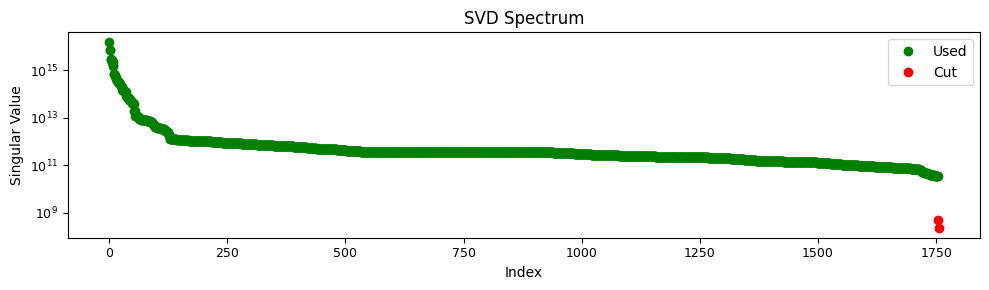

  LM inner 1: chi² 8.5302e+04 (previous 5.0987e+06), λ=0.001
Chi² after correction: 8.5302e+04

==== Iteration 2/5 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 2)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs2.txt'
   No outliers in the data set.
Initial Chi²: 8.5302e+04


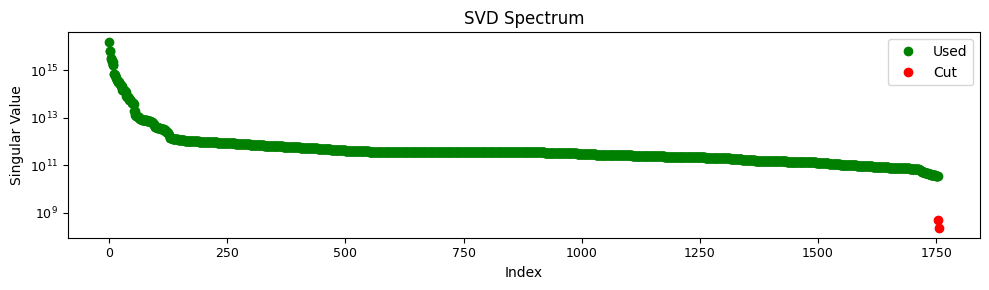

  LM inner 1: chi² 7.1844e+04 (previous 8.5302e+04), λ=0.001
Chi² after correction: 7.1844e+04

==== Iteration 3/5 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 3)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs2.txt'
   std(Model-Measurement) = 0.002599 mm (with outliers)
   2 outliers removed out of 184320 points (> 10 sigma) (2 first test + 0 second test).
Initial Chi²: 7.1844e+04


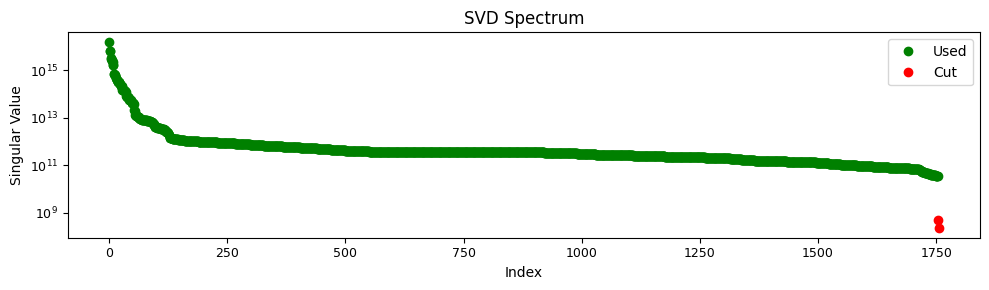

  LM inner 1: chi² 7.1412e+04 (previous 7.1844e+04), λ=0.001
Chi² after correction: 7.1342e+04

==== Iteration 4/5 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 4)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs2.txt'
   std(Model-Measurement) = 0.002592 mm (with outliers)
   2 outliers removed out of 184320 points (> 10 sigma) (2 first test + 0 second test).
Initial Chi²: 7.1342e+04


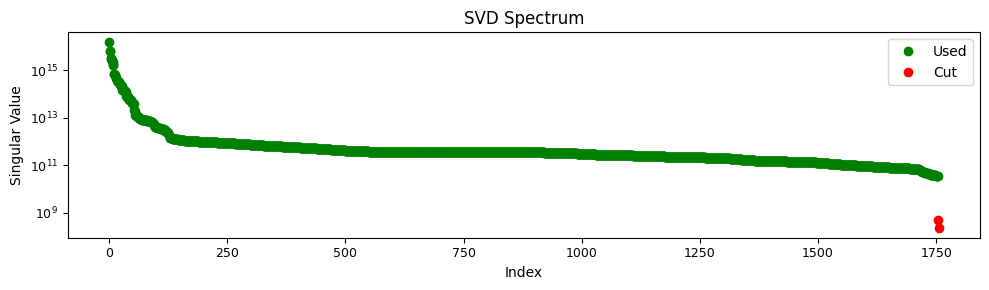

  LM inner 1: chi² 7.1187e+04 (previous 7.1342e+04), λ=0.001
Chi² after correction: 7.1187e+04

==== Iteration 5/5 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 5)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs2.txt'
   std(Model-Measurement) = 0.002589 mm (with outliers)
   2 outliers removed out of 184320 points (> 10 sigma) (2 first test + 0 second test).
Initial Chi²: 7.1187e+04


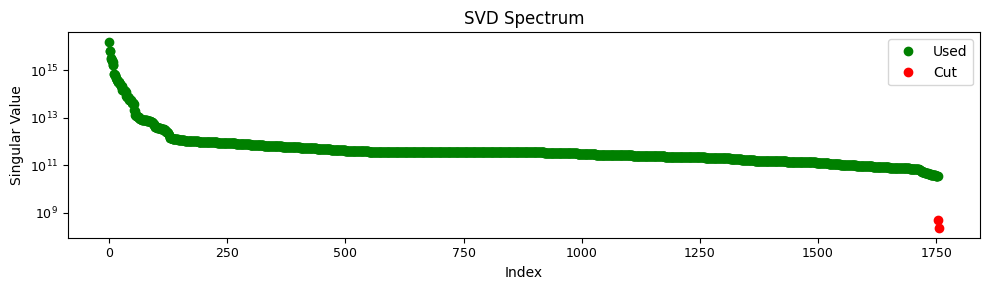

  LM inner 1: chi² 7.1100e+04 (previous 7.1187e+04), λ=0.001
Chi² after correction: 7.1100e+04
LOCO LM completed! :).


In [3]:
from analyze_ring import analyze_ring

print('Before_pyLOCO_iteration')
elements_ind = at.get_refpts(SC.lattice.design, '*')
analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

# run pyloco
orm = np.hstack((orm, eta.reshape(-1, 1))) #When include_dispersion is true in the config
config_path =  os.path.abspath("pyloco_config.py")
current_fit_parameters, fit_parameters_dic, ring_pyloco = run_pyloco_from_model(
                        orm, sigma_w,  etax,  etay,  config_path=config_path
                    )

In [ ]:
# apply correction

print('Before_pyLOCO_iteration')
_, _, twiss0 = at.get_optics(SC.lattice.design, elements_ind)
analyze_ring(SC, twiss0, elements_ind, useIdealRing=False, makeplot=False)

quad_indices = at.get_refpts(SC.lattice.design, at.elements.Quadrupole)
QD3 = at.get_refpts(SC.lattice.design, 'QD3[AE]*')
QF4 = at.get_refpts(SC.lattice.design, 'QF4[ABDE]*')
QD5 = at.get_refpts(SC.lattice.design, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
skew_ord = at.get_refpts(SC.lattice.design, 'S[HFDIJ]*')
inner = last_by_sorted_key(fit_parameters_dic)
quads_fit, skew_fit = get_quads_block(inner)
delta_q = np.asarray(
[quads_fit[i] - SC.lattice.design[quad_indices[i]].K for i in range(len(quad_indices))],
dtype = float
).ravel()

#delta_skew = np.asarray(
#[skew_fit[i] - SC.lattice.design[skew_ord[i]].K for i in range(len(skew_ord))],
#dtype = float
#).ravel()

set_correction(SC, -delta_q, quad_indices, individuals=True, skewness=False)
#set_correction(SC, -delta_skew, skew_ord, individuals=True, skewness=True)

print('After_pyLOCO_iteration')
_, _, twiss0 = at.get_optics(SC.lattice.design, elements_ind)
analyze_ring(SC, twiss0, elements_ind, useIdealRing=False, makeplot=False)

After_pyLOCO_iteration
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   5.2885 µm
RMS vertical orbit           :   6.6344 µm
RMS horizontal beta beating  :   0.7981 %
RMS vertical beta beating    :   0.8612 %
RMS horizontal dispersion err:   3.3093 mm
RMS vertical dispersion err  :   0.0921 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569022e-03]
Tune                         : [7.61509404e+01 2.73399314e+01 3.68325367e-03]
Chromaticity                 : [-1.08155465e+02 -8.17051184e+01  3.09110863e-02]
Ideal emittance_h 140.83912733792073 emittance_v 0.0
With errors emittance_h 145.71831066945677 emittance_v 0.0
----------------------------------------------------------------------
